In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ETUDIANTS.csv")

In [3]:
df

,ANALYSE,ANNEE,SEXE,TRANCHE_AGE,NB_ETUDIANTS,REGION,POPULATION,PCT_OCR,PCT_FRANCE,ECART_PTS
0,AGE,NaN,TOUS,20-24 ans,190,TOUS,3949118.0,4.09,7.53,-3.44
1,AGE,NaN,TOUS,25-29 ans,912,TOUS,3827636.0,19.63,7.30,12.33
2,AGE,NaN,TOUS,30-34 ans,1186,TOUS,4097259.0,25.52,7.81,17.71
3,AGE,NaN,TOUS,35-39 ans,863,TOUS,4270271.0,18.57,8.14,10.43
4,AGE,NaN,TOUS,40-44 ans,609,TOUS,4334986.0,13.11,8.27,4.84
5,AGE,NaN,TOUS,45-49 ans,395,TOUS,4220756.0,8.50,8.05,0.45
6,AGE,NaN,TOUS,50-54 ans,266,TOUS,4514139.0,5.72,8.61,-2.88
7,AGE,NaN,TOUS,55-59 ans,153,TOUS,4435810.0,3.29,8.46,-5.17
8,AGE,NaN,TOUS,60 ans ou plus,73,TOUS,18786277.0,1.57,35.83,-34.26
9,REGION,NaN,TOUS,TOUS,435,Auvergne-Rhône-Alpes,6280020.0,9.36,12.04,-2.68


### 📈 Indicateurs à Calculer (Idées)



#### Par dimension temporelle
- Évolution du nombre d'inscrits par année
- Tendance des tranches d'âge (rajeunissement ? vieillissement ?)



In [4]:
df_year = df.query("ANALYSE == 'YEAR'")
df_year

,ANALYSE,ANNEE,SEXE,TRANCHE_AGE,NB_ETUDIANTS,REGION,POPULATION,PCT_OCR,PCT_FRANCE,ECART_PTS
24,YEAR,2022.0,TOUS,TOUS,1696,TOUS,NaN,NaN,NaN,NaN
25,YEAR,2023.0,TOUS,TOUS,1150,TOUS,NaN,NaN,NaN,NaN
26,YEAR,2024.0,TOUS,TOUS,850,TOUS,NaN,NaN,NaN,NaN
27,YEAR,2025.0,TOUS,TOUS,951,TOUS,NaN,NaN,NaN,NaN


int64


C:\Users\trist\AppData\Local\Temp\ipykernel_18700\3559264018.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_year['ANNEE'] = df_year['ANNEE'].astype(int)


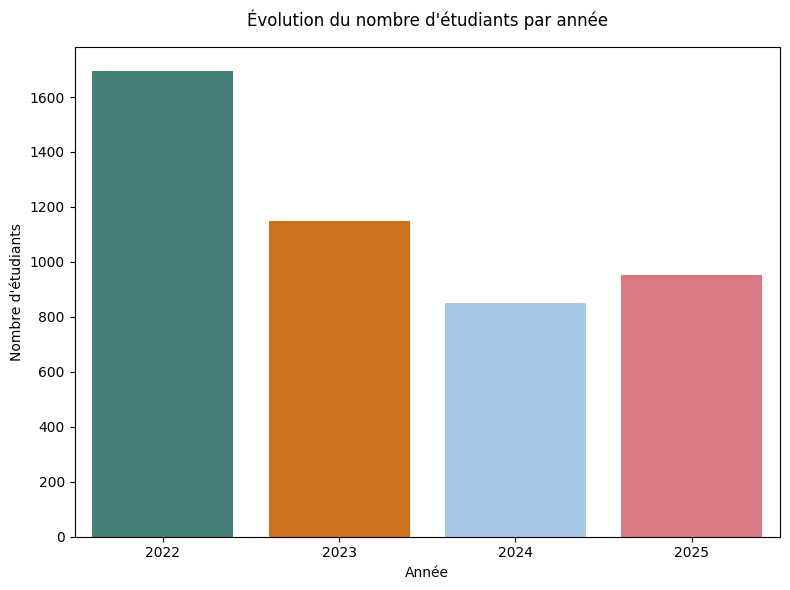

In [15]:
df_year['ANNEE'] = df_year['ANNEE'].astype(int)
print(df_year['ANNEE'].dtype)
palette = ['#3b8880', '#ea7000', '#9cc7f2', '#e96b7c']
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=df_year, x='ANNEE', y='NB_ETUDIANTS', ax=ax, hue='ANNEE', palette=palette, legend=False)
ax.set_title('Évolution du nombre d\'étudiants par année', pad=15)
ax.set_xlabel('Année')
ax.set_ylabel('Nombre d\'étudiants')
plt.tight_layout()
plt.show()

#### Par dimension géographique
- Répartition régionale vs population française (INSEE)
- Régions sur/sous-représentées

In [6]:
df_region = df.query("ANALYSE == 'REGION'")
df_region

,ANALYSE,ANNEE,SEXE,TRANCHE_AGE,NB_ETUDIANTS,REGION,POPULATION,PCT_OCR,PCT_FRANCE,ECART_PTS
9,REGION,NaN,TOUS,TOUS,435,Auvergne-Rhône-Alpes,6280020.0,9.36,12.04,-2.68
10,REGION,NaN,TOUS,TOUS,78,Bourgogne-Franche-Comté,2181645.0,1.68,4.18,-2.50
11,REGION,NaN,TOUS,TOUS,139,Bretagne,2679977.0,2.99,5.14,-2.15
12,REGION,NaN,TOUS,TOUS,122,Centre-Val de Loire,1990766.0,2.63,3.82,-1.19
13,REGION,NaN,TOUS,TOUS,46,DROM,1533013.0,0.99,2.94,-1.95
14,REGION,NaN,TOUS,TOUS,256,Grand Est,4314267.0,5.51,8.27,-2.76
15,REGION,NaN,TOUS,TOUS,300,Hauts-de-France,4501677.0,6.46,8.63,-2.18
16,REGION,NaN,TOUS,TOUS,114,Normandie,2571275.0,2.45,4.93,-2.48
17,REGION,NaN,TOUS,TOUS,296,Nouvelle-Aquitaine,4869523.0,6.37,9.34,-2.97
18,REGION,NaN,TOUS,TOUS,287,Occitanie,4805204.0,6.18,9.21,-3.04


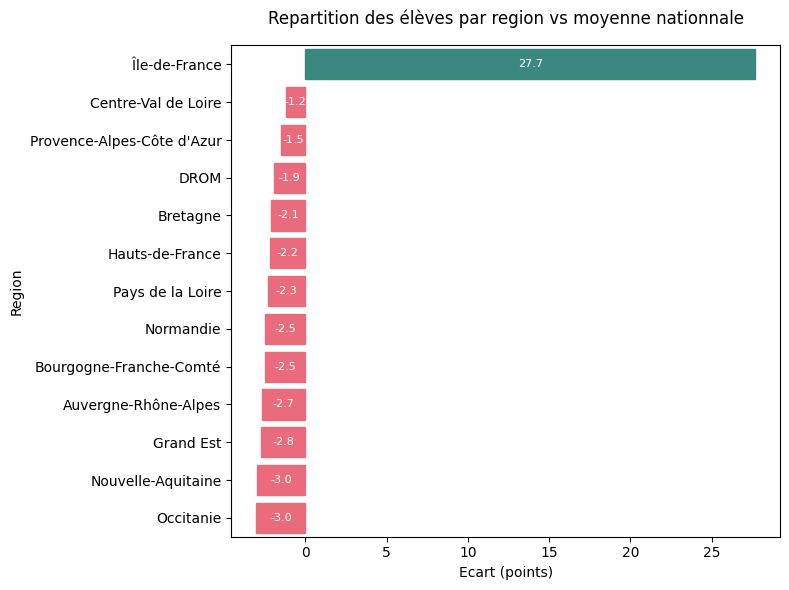

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=df_region.sort_values('ECART_PTS', ascending=False), x='ECART_PTS', y='REGION', ax=ax)
ax.set_title('Repartition des élèves par region vs moyenne nationnale', pad=15)
ax.set_xlabel('Ecart (points)')
ax.set_ylabel('Region')
plt.tight_layout()
for bar, val in zip(ax.patches, df_region.sort_values('ECART_PTS', ascending=False)['ECART_PTS']):
    bar.set_color("#3b8880" if val > 0 else "#e96b7c")
    ax.text(bar.get_width()/2 if val > 0 else bar.get_width()/2, 
        bar.get_y() + bar.get_height()/2, 
        f'{val:.1f}', va='center', ha='center',
        color='white', fontsize=8)
plt.show()

#### Par dimension sociodémographique
- Répartition H/F
- Comparaison avec la population active française

In [8]:
df_sexe = df.query("ANALYSE == 'SEXE'")
df_sexe

,ANALYSE,ANNEE,SEXE,TRANCHE_AGE,NB_ETUDIANTS,REGION,POPULATION,PCT_OCR,PCT_FRANCE,ECART_PTS
22,SEXE,NaN,F,TOUS,1057,TOUS,27466074.0,31.08,52.38,-21.3
23,SEXE,NaN,M,TOUS,2344,TOUS,24970176.0,68.92,47.62,21.3


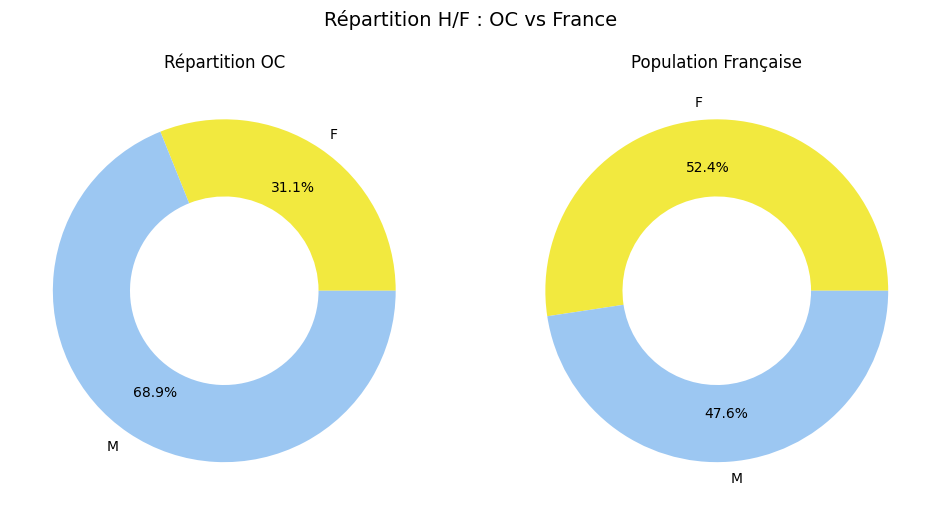

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Données
labels = df_sexe['SEXE']
pct_oc = df_sexe['PCT_OCR']
pct_fr = df_sexe['PCT_FRANCE']
colors = ['#f2e93f', '#9cc7f2']

# Donut OC
ax1.pie(pct_oc, labels=labels, colors=colors, autopct='%1.1f%%', pctdistance=0.72,  
        wedgeprops=dict(width=0.45), textprops={'color': 'black'})
ax1.set_title('Répartition OC')


# Donut France
ax2.pie(pct_fr, labels=labels, colors=colors, autopct='%1.1f%%', pctdistance=0.72,
        wedgeprops=dict(width=0.45), textprops={'color': 'black'})
ax2.set_title('Population Française')


fig.suptitle('Répartition H/F : OC vs France', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

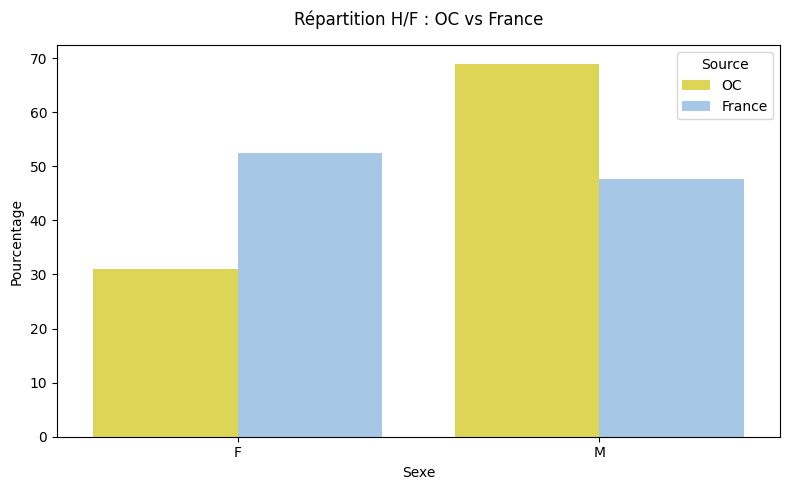

In [10]:
df_sexe = df_sexe.rename(columns={'PCT_OCR': 'OC', 'PCT_FRANCE': 'France', 'SEXE': 'Sexe'})
df_melted = df_sexe[['Sexe', 'OC', 'France']].melt(
    id_vars='Sexe', 
    var_name='Source', 
    value_name='Pourcentage'
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_melted, x='Sexe', y='Pourcentage', hue='Source', 
            palette=['#f2e93f', '#9cc7f2'], ax=ax)
ax.set_title('Répartition H/F : OC vs France', pad=15)
plt.tight_layout()
plt.show()

#### Par dimension générationnelle
- Répartition par tranches d'ages
- Comparaison avec la population active française

In [11]:
df_age = df.query("ANALYSE == 'AGE'")
df_age

,ANALYSE,ANNEE,SEXE,TRANCHE_AGE,NB_ETUDIANTS,REGION,POPULATION,PCT_OCR,PCT_FRANCE,ECART_PTS
0,AGE,NaN,TOUS,20-24 ans,190,TOUS,3949118.0,4.09,7.53,-3.44
1,AGE,NaN,TOUS,25-29 ans,912,TOUS,3827636.0,19.63,7.30,12.33
2,AGE,NaN,TOUS,30-34 ans,1186,TOUS,4097259.0,25.52,7.81,17.71
3,AGE,NaN,TOUS,35-39 ans,863,TOUS,4270271.0,18.57,8.14,10.43
4,AGE,NaN,TOUS,40-44 ans,609,TOUS,4334986.0,13.11,8.27,4.84
5,AGE,NaN,TOUS,45-49 ans,395,TOUS,4220756.0,8.50,8.05,0.45
6,AGE,NaN,TOUS,50-54 ans,266,TOUS,4514139.0,5.72,8.61,-2.88
7,AGE,NaN,TOUS,55-59 ans,153,TOUS,4435810.0,3.29,8.46,-5.17
8,AGE,NaN,TOUS,60 ans ou plus,73,TOUS,18786277.0,1.57,35.83,-34.26


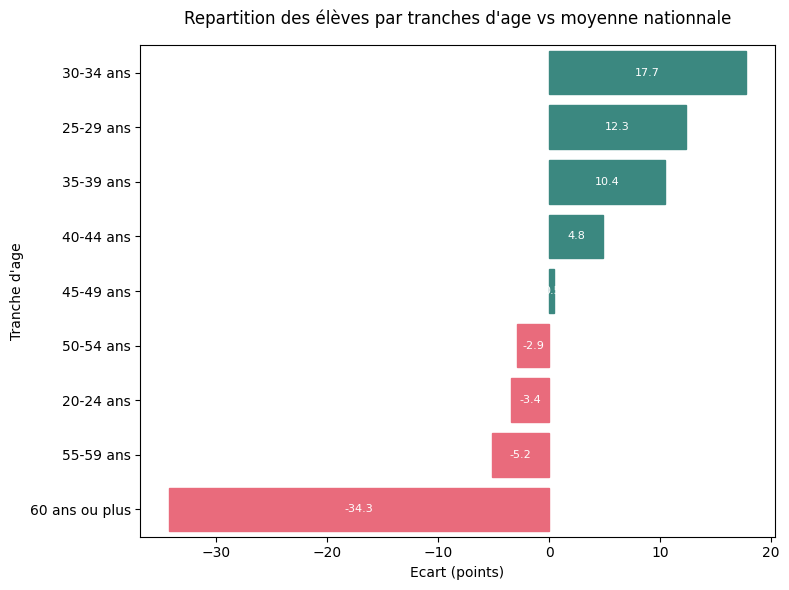

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=df_age.sort_values('ECART_PTS', ascending=False), x='ECART_PTS', y='TRANCHE_AGE', ax=ax)
ax.set_title('Repartition des élèves par tranches d\'age vs moyenne nationnale', pad=15)
ax.set_xlabel('Ecart (points)')
ax.set_ylabel('Tranche d\'age')
plt.tight_layout()
for bar, val in zip(ax.patches, df_age.sort_values('ECART_PTS', ascending=False)['ECART_PTS']):
    bar.set_color("#3b8880" if val > 0 else "#e96b7c")
    ax.text(bar.get_width()/2 if val > 0 else bar.get_width()/2, 
        bar.get_y() + bar.get_height()/2, 
        f'{val:.1f}', va='center', ha='center',
        color='white', fontsize=8)
plt.show()